# Customer Churn Prediction

## Importing basic libraries

In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
pd.set_option('display.max_columns', None)

## Reading the dataset

In [2]:
df = pd.read_csv("../Customer_Data/customer_churn_data.csv")
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


## Getting statistical info and shape of the dataset

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Checking Missing Values

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Observation:No missing values are present in the dataset

## Checking duplicate records

In [7]:
df.duplicated().sum()

np.int64(0)

### Observation:No duplicate records are present in the dataset

## Getting all column names

In [14]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Getting unique values in each column 

In [11]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [9]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [13]:
print(f"Unique values in the column gender are : {list(df.gender.unique())}")
print(f"Unique values in the column SeniorCitizen are : {list(df.SeniorCitizen.unique())}")

print(f"Unique values in the column Partner are : {list(df.Partner.unique())}")
print(f"Unique values in the column Dependents are : {list(df.Dependents.unique())}")

print(f"Unique values in the column PhoneService are : {list(df.PhoneService.unique())}")
print(f"Unique values in the column MultipleLines are : {list(df.MultipleLines.unique())}")

print(f"Unique values in the column InternetService are : {list(df.InternetService.unique())}")
print(f"Unique values in the column OnlineSecurity are : {list(df.OnlineSecurity.unique())}")

print(f"Unique values in the column OnlineBackup are : {list(df.OnlineBackup.unique())}")
print(f"Unique values in the column DeviceProtection are : {list(df.DeviceProtection.unique())}")

print(f"Unique values in the column TechSupport are : {list(df.TechSupport.unique())}")
print(f"Unique values in the column StreamingTV are : {list(df.StreamingTV.unique())}")

print(f"Unique values in the column StreamingMovies are : {list(df.StreamingMovies.unique())}")
print(f"Unique values in the column Contract are : {list(df.Contract.unique())}")

print(f"Unique values in the column PaperlessBilling are : {list(df.PaperlessBilling.unique())}")
print(f"Unique values in the column PaymentMethod are : {list(df.PaymentMethod.unique())}")

print(f"Unique values in the column Churn are : {list(df.Churn.unique())}")

Unique values in the column gender are : ['Female', 'Male']
Unique values in the column SeniorCitizen are : [np.int64(0), np.int64(1)]
Unique values in the column Partner are : ['Yes', 'No']
Unique values in the column Dependents are : ['No', 'Yes']
Unique values in the column PhoneService are : ['No', 'Yes']
Unique values in the column MultipleLines are : ['No phone service', 'No', 'Yes']
Unique values in the column InternetService are : ['DSL', 'Fiber optic', 'No']
Unique values in the column OnlineSecurity are : ['No', 'Yes', 'No internet service']
Unique values in the column OnlineBackup are : ['Yes', 'No', 'No internet service']
Unique values in the column DeviceProtection are : ['No', 'Yes', 'No internet service']
Unique values in the column TechSupport are : ['No', 'Yes', 'No internet service']
Unique values in the column StreamingTV are : ['No', 'Yes', 'No internet service']
Unique values in the column StreamingMovies are : ['No', 'Yes', 'No internet service']
Unique values in 

In [15]:
df.info(
    
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

ValueError: could not convert string to float: ' '

In [17]:
df[df["TotalCharges"]==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Observation: There are 11 rows which have 'TotalCharges' as blank string and 'Tenure' as zero.

## Getting Numerical and Categorical features

In [18]:
num_features = [feature for feature in df.columns if df[feature].dtype!="O"]
cat_features = [feature for feature in df.columns if df[feature].dtype=="O"]

print(f"There are {len(num_features)} numerical features named {num_features}")
print(f"There are {len(cat_features)} categorical features named {cat_features}")

There are 3 numerical features named ['SeniorCitizen', 'tenure', 'MonthlyCharges']
There are 18 categorical features named ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


## Checking value counts of the target column

In [19]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: ylabel='count'>

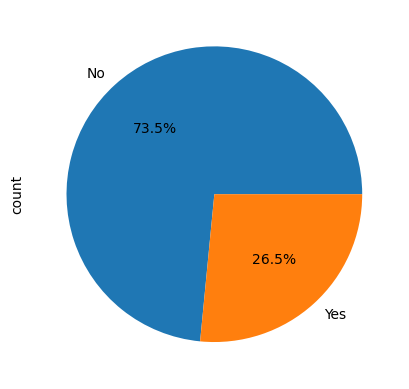

In [22]:
df.Churn.value_counts().plot(kind="pie",autopct="%1.1f%%")